In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/erickavendanogarcia/Desktop/ML_physics/football_data.csv")  # o "windows-1252"

In [2]:
df

,liga,temporada,equipo,fecha,sede,asistencia,arbitro,id,G,A,...,GK_rival,Ti_rival,GOTB_rival,RFG_rival,LFG_rival,HG_rival,PG_rival,GFSP_rival,contrincante_rival,posicion_rival
0,Liga MX,2024/2025,CSyD Atlas de Guadalajara,17 de septiembre de 2024,Estadio Ciudad de los Deportes,10236.0,Adonai Escobedo Gonzï¿½ï¿,amï¿½ï¿½rica_atlas.guadalajara_1709,0,0,...,8,15,1,2,1,0,0,0,CSyD Atlas de Guadalajara,Local
1,Liga MX,2024/2025,Club Amï¿½ï¿½,17 de septiembre de 2024,Estadio Ciudad de los Deportes,10236.0,Adonai Escobedo Gonzï¿½ï¿,amï¿½ï¿½rica_atlas.guadalajara_1709,3,3,...,11,18,0,0,0,0,0,0,Club Amï¿½ï¿½,Visitante
2,Liga MX,2023/2024,CSyD Atlas de Guadalajara,20 de agosto de 2023,Estadio Azteca,17046.0,Adonai Escobedo Gonzï¿½ï¿,amï¿½ï¿½rica_atlas.guadalajara_2008,1,1,...,8,28,0,0,1,0,0,0,CSyD Atlas de Guadalajara,Local
3,Liga MX,2023/2024,Club Amï¿½ï¿½,20 de agosto de 2023,Estadio Azteca,17046.0,Adonai Escobedo Gonzï¿½ï¿,amï¿½ï¿½rica_atlas.guadalajara_2008,1,1,...,13,13,0,1,0,0,0,0,Club Amï¿½ï¿½,Visitante
4,Liga MX,2023/2024,Club Amï¿½ï¿½,24 de febrero de 2024,Estadio Azteca,59032.0,ýýscar Mejýýa Garcýýa,amï¿½ï¿½rica_cruz.azul_2402,1,1,...,2,19,0,0,0,0,0,0,Club Amï¿½ï¿½,Visitante
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,UEFA Champions League,2024/2025,VfB Stuttgart 1893,6 de noviembre de 2024,MHPArena,60000.0,Rade Obrenoviï¿,vfb.stuttgart.1893_atalanta.bergamasca.calcio_...,0,0,...,9,11,0,0,2,0,0,0,VfB Stuttgart 1893,Visitante
1800,UEFA Champions League,2024/2025,BSC Young Boys,11 de diciembre de 2024,MHPArena,60000.0,Giorgi Kruashvili,vfb.stuttgart.1893_bsc.young.boys_11122024,1,1,...,3,23,2,3,2,0,0,0,BSC Young Boys,Local
1801,UEFA Champions League,2024/2025,VfB Stuttgart 1893,11 de diciembre de 2024,MHPArena,60000.0,Giorgi Kruashvili,vfb.stuttgart.1893_bsc.young.boys_11122024,5,5,...,8,14,1,0,1,0,0,0,VfB Stuttgart 1893,Visitante
1802,UEFA Champions League,2024/2025,Paris Saint-Germain FC,29 de enero de 2025,MHPArena,60000.0,Davide Massa,vfb.stuttgart.1893_paris.saint-germain_29012025,4,4,...,4,19,0,0,0,0,0,0,Paris Saint-Germain FC,Local


## 1.1 Una pequeña limpieza de datos

In [3]:
from datetime import datetime

def convertir_fecha(fecha_str):
    meses = {
        'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
        'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
        'septiembre': '09', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
    }

    partes = fecha_str.split(' de ')
    dia = partes[0].zfill(2)  # Asegurar que el día tenga dos dígitos
    mes = meses[partes[1].lower()]
    año = partes[2]

    return f"{año}-{mes}-{dia}"


df['fecha_convertida'] = df['fecha'].apply(convertir_fecha)

df = df.sort_values(by='fecha_convertida').reset_index(drop=True)

In [4]:
df

,liga,temporada,equipo,fecha,sede,asistencia,arbitro,id,G,A,...,Ti_rival,GOTB_rival,RFG_rival,LFG_rival,HG_rival,PG_rival,GFSP_rival,contrincante_rival,posicion_rival,fecha_convertida
0,Liga MX,2023/2024,Club Amï¿½ï¿½,30 de junio de 2023,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,1,0,...,20,1,2,0,0,0,0,Club Amï¿½ï¿½,Visitante,2023-06-30
1,Liga MX,2023/2024,Mazatlï¿½ï¿½,30 de junio de 2023,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,...,25,0,1,0,0,0,0,Mazatlï¿½ï¿½,Visitante,2023-06-30
2,Liga MX,2023/2024,CF Pachuca,30 de junio de 2023,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,...,20,0,1,0,0,0,0,CF Pachuca,Local,2023-06-30
3,Liga MX,2023/2024,FC Juï¿½ï¿,30 de junio de 2023,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,2,2,...,22,1,0,1,0,0,1,FC Juï¿½ï¿,Local,2023-06-30
4,Liga MX,2023/2024,Club Tijuana Xoloitzcuintles de Caliente,30 de junio de 2023,Estadio Caliente,26333.0,Daniel Quintero Huittrï¿½,tijuana.xoloitzcuintles.caliente_pumas.la.univ...,2,1,...,23,0,3,0,0,1,0,Club Tijuana Xoloitzcuintles de Caliente,Visitante,2023-06-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,Liga MX,2024/2025,Club Leï¿½,8 de febrero de 2025,Estadio Leï¿½ï¿½n (Nou Ca,25425.0,Marco Antonio Ortï¿½ï¿½z,leï¿½ï¿½n_toluca_802,3,3,...,13,0,3,0,0,0,0,Club Leï¿½,Visitante,2025-02-08
1800,Liga MX,2024/2025,Club Tijuana Xoloitzcuintles de Caliente,9 de febrero de 2025,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,1,1,...,22,0,1,1,0,0,0,Club Tijuana Xoloitzcuintles de Caliente,Local,2025-02-09
1801,Liga MX,2024/2025,Mazatlï¿½ï¿½,9 de febrero de 2025,Estadio Olï¿½ï¿½mpico Universita,8845.0,Vï¿½ï¿½ctor Alfonso Cï¿½ï¿½ceres He,pumas.la.universidad.nacional.autonoma.mexico_...,0,0,...,25,0,1,0,0,0,0,Mazatlï¿½ï¿½,Local,2025-02-09
1802,Liga MX,2024/2025,CD Guadalajara,9 de febrero de 2025,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,2,2,...,23,0,0,0,1,0,0,CD Guadalajara,Visitante,2025-02-09


In [5]:
df.drop(['fecha'], axis=1)

,liga,temporada,equipo,sede,asistencia,arbitro,id,G,A,TR,...,Ti_rival,GOTB_rival,RFG_rival,LFG_rival,HG_rival,PG_rival,GFSP_rival,contrincante_rival,posicion_rival,fecha_convertida
0,Liga MX,2023/2024,Club Amï¿½ï¿½,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,1,0,0,...,20,1,2,0,0,0,0,Club Amï¿½ï¿½,Visitante,2023-06-30
1,Liga MX,2023/2024,Mazatlï¿½ï¿½,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,0,...,25,0,1,0,0,0,0,Mazatlï¿½ï¿½,Visitante,2023-06-30
2,Liga MX,2023/2024,CF Pachuca,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,0,...,20,0,1,0,0,0,0,CF Pachuca,Local,2023-06-30
3,Liga MX,2023/2024,FC Juï¿½ï¿,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,2,2,0,...,22,1,0,1,0,0,1,FC Juï¿½ï¿,Local,2023-06-30
4,Liga MX,2023/2024,Club Tijuana Xoloitzcuintles de Caliente,Estadio Caliente,26333.0,Daniel Quintero Huittrï¿½,tijuana.xoloitzcuintles.caliente_pumas.la.univ...,2,1,0,...,23,0,3,0,0,1,0,Club Tijuana Xoloitzcuintles de Caliente,Visitante,2023-06-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,Liga MX,2024/2025,Club Leï¿½,Estadio Leï¿½ï¿½n (Nou Ca,25425.0,Marco Antonio Ortï¿½ï¿½z,leï¿½ï¿½n_toluca_802,3,3,0,...,13,0,3,0,0,0,0,Club Leï¿½,Visitante,2025-02-08
1800,Liga MX,2024/2025,Club Tijuana Xoloitzcuintles de Caliente,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,1,1,1,...,22,0,1,1,0,0,0,Club Tijuana Xoloitzcuintles de Caliente,Local,2025-02-09
1801,Liga MX,2024/2025,Mazatlï¿½ï¿½,Estadio Olï¿½ï¿½mpico Universita,8845.0,Vï¿½ï¿½ctor Alfonso Cï¿½ï¿½ceres He,pumas.la.universidad.nacional.autonoma.mexico_...,0,0,0,...,25,0,1,0,0,0,0,Mazatlï¿½ï¿½,Local,2025-02-09
1802,Liga MX,2024/2025,CD Guadalajara,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,2,2,0,...,23,0,0,0,1,0,0,CD Guadalajara,Visitante,2025-02-09


## 2.1 Análisis de Goles por fecha

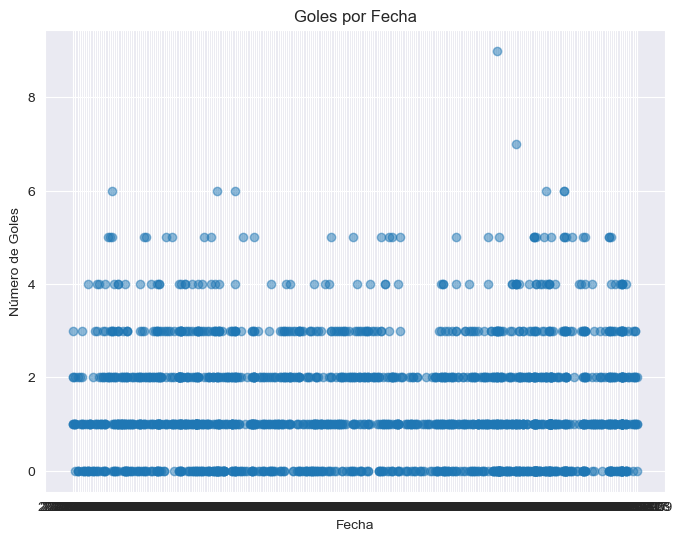

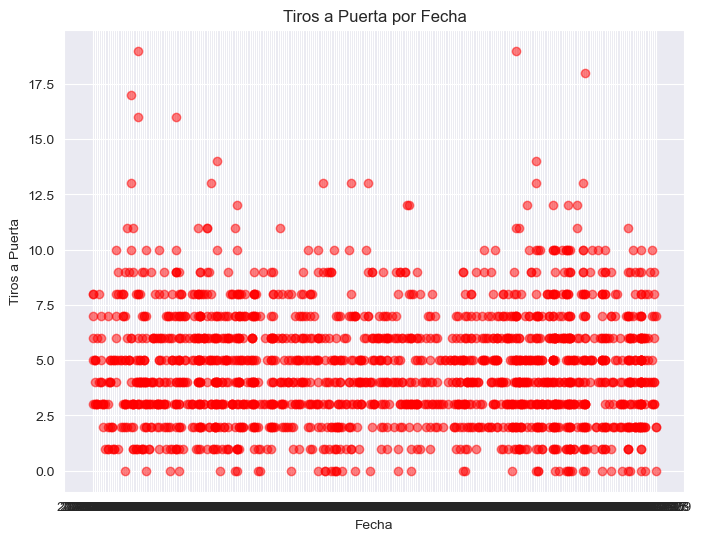

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(df["fecha_convertida"], df["G"], alpha=0.5)
plt.title("Goles por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Número de Goles")
plt.grid(True)
plt.show()

# Mejorando visualización con relación tiros a gol
plt.figure(figsize=(8,6))
plt.scatter(df["fecha_convertida"], df["SOnT"], alpha=0.5, color='red')
plt.title("Tiros a Puerta por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Tiros a Puerta")
plt.grid(True)
plt.show()

/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_3801/2093826199.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_mensual = df.resample('M', on='fecha_convertida').sum()  # También puedes usar .mean() según lo que necesites


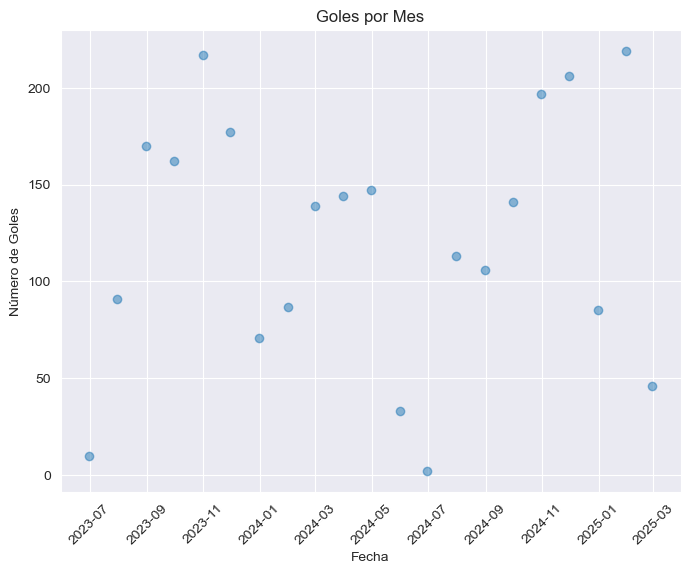

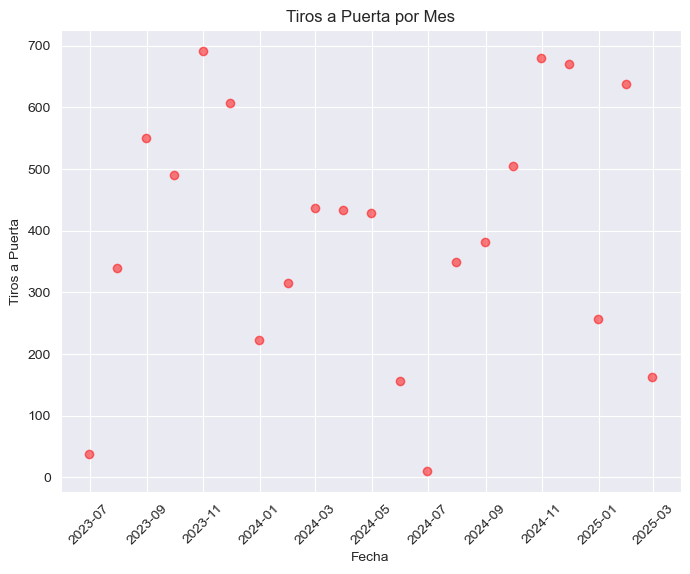

In [7]:
# Asegurarse de que 'fecha_convertida' sea datetime
df["fecha_convertida"] = pd.to_datetime(df["fecha_convertida"])

# Agrupar por mes y calcular la suma o promedio de goles y tiros a puerta
df_mensual = df.resample('M', on='fecha_convertida').sum()  # También puedes usar .mean() según lo que necesites

plt.figure(figsize=(8,6))
plt.scatter(df_mensual.index, df_mensual["G"], alpha=0.5)
plt.title("Goles por Mes")
plt.xlabel("Fecha")
plt.ylabel("Número de Goles")
plt.grid(True)
plt.xticks(rotation=45)  # Para mejorar la visualización de fechas
plt.show()

# Mejorando visualización con relación tiros a gol
plt.figure(figsize=(8,6))
plt.scatter(df_mensual.index, df_mensual["SOnT"], alpha=0.5, color='red')
plt.title("Tiros a Puerta por Mes")
plt.xlabel("Fecha")
plt.ylabel("Tiros a Puerta")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [8]:
df["equipo"].unique()

array(['Club Amï¿½ï¿½', 'Mazatlï¿½ï¿½', 'CF Pachuca', 'FC Juï¿½ï¿',
       'Club Tijuana Xoloitzcuintles de Caliente',
       'Pumas de la Universidad Nacional Autonoma de Mexico',
       'CF Tigres de la Universidad Autï¿½ï¿½noma de Nuevo L',
       'Puebla FC', 'CSyD Atlas de Guadalajara', 'Cruz Azul FC',
       'CF Monterrey', 'Atlï¿½ï¿½tico de San ', 'Querï¿½ï¿½tar',
       'Club Necaxa', 'Deportivo Toluca FC', 'Club Santos Laguna',
       'Club Leï¿½', 'CD Guadalajara', 'Maccabi Haifa FC',
       'Hï¿½ï¿½K Zrinjski Mo', 'Ferencvï¿½ï¿½ros', 'Kï¿½ï¿½ Klaks',
       'Hamrun Spartans FC', 'FC Urartu', 'FCV Farul Constanï¿½',
       'FK Astana', 'ýýK Slovan Bratislava', 'FK Sheriff Tiraspol',
       'FC Dinamo Tbilisi', 'FC Swift Hesperange', 'FK ï¿½ï¿½algiris Vil',
       'FC Struga Trim-Lum', 'FK Valmiera', 'NK Olimpija Ljubljana',
       'KRC Genk', 'FC Copenhague', 'SK Dnipro-1', 'Panathinaikos FC',
       'GNK Dinamo Zagreb', 'Servette FC', 'Breidablik UBK',
       'Qarabaï¿½ï¿½ A

# Comparación de Distribución de Goles por Liga


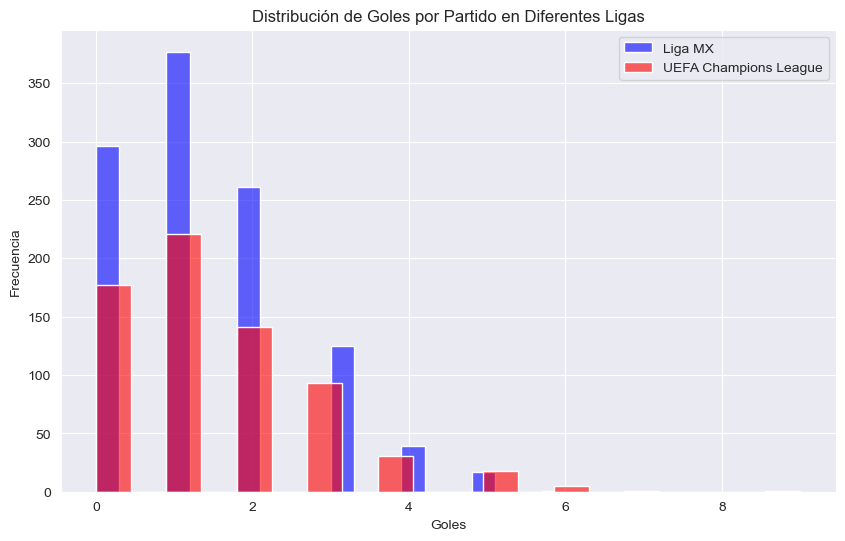

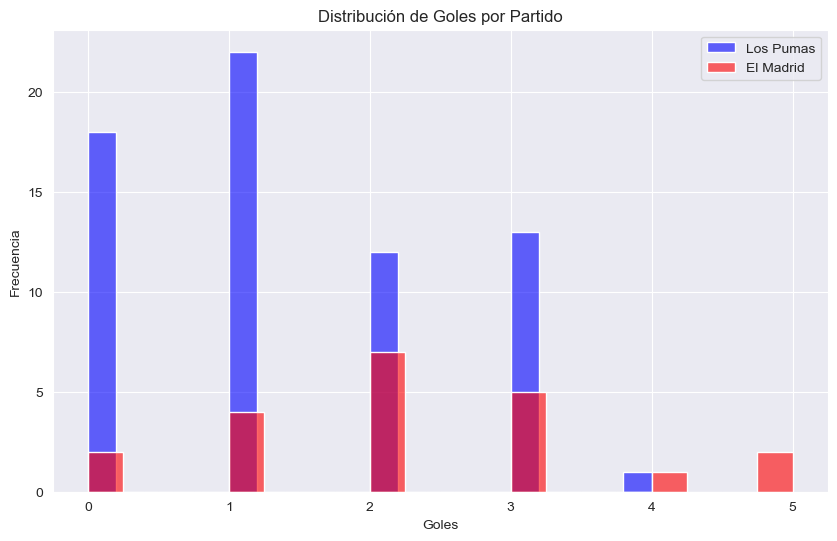

In [9]:
# Sección 5: Histogramas Comparativos por Liga
# ========================
import seaborn as sns
print("# Comparación de Distribución de Goles por Liga")

ligas = ["Liga MX", "UEFA Champions League"]
df_ligas = df[df["liga"].isin(ligas)]

plt.figure(figsize=(10,6))
sns.histplot(df_ligas[df_ligas["liga"] == "Liga MX"]["G"], bins=20, color="blue", label="Liga MX", alpha=0.6)
sns.histplot(df_ligas[df_ligas["liga"] == "UEFA Champions League"]["G"], bins=20, color="red", label="UEFA Champions League", alpha=0.6)

plt.title("Distribución de Goles por Partido en Diferentes Ligas")
plt.xlabel("Goles")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

equipos = ["Pumas de la Universidad Nacional Autonoma de Mexico", "Real Madrid CF"]
df_equipos = df[df["equipo"].isin(equipos)]

plt.figure(figsize=(10,6))
sns.histplot(df_equipos[df_equipos["equipo"] == "Pumas de la Universidad Nacional Autonoma de Mexico"]["G"], bins=20, color="blue", label="Los Pumas", alpha=0.6)
sns.histplot(df_equipos[df_equipos["equipo"] == "Real Madrid CF"]["G"], bins=20, color="red", label="El Madrid", alpha=0.6)

plt.title("Distribución de Goles por Partido")
plt.xlabel("Goles")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

# Comparación de Equipos


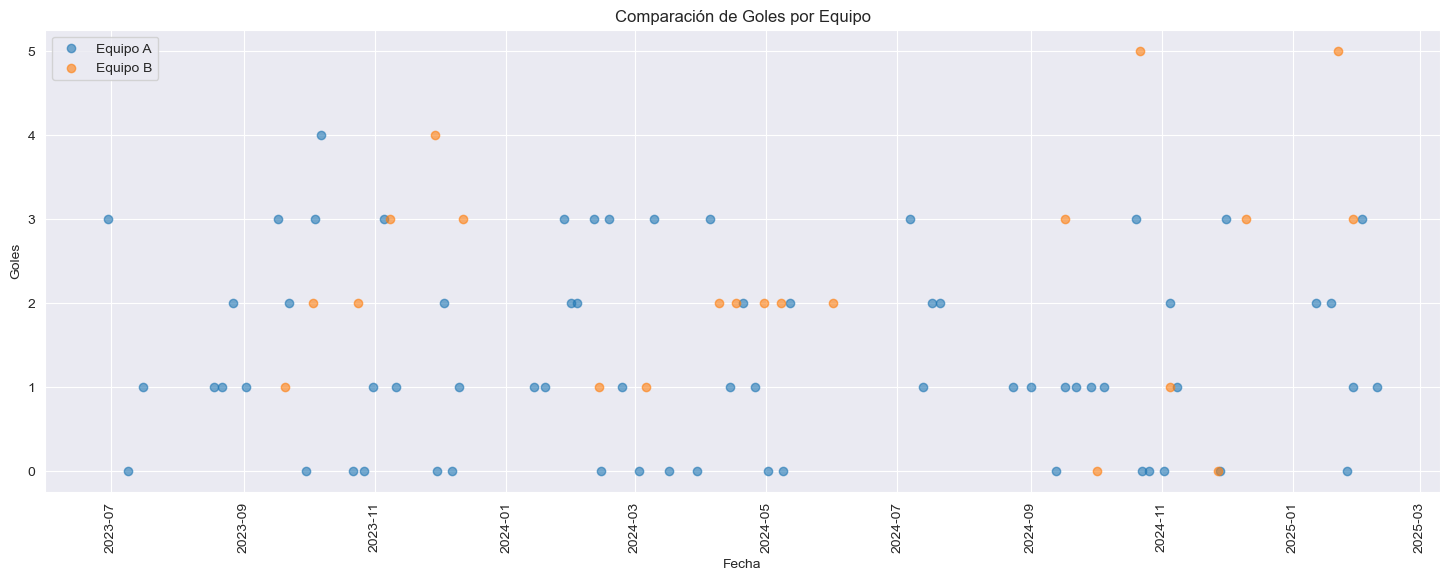

In [10]:
# ========================
# Sección 6: Comparación de Equipos
# ========================
print("# Comparación de Equipos")

equipo1 = df[df["equipo"] == "Pumas de la Universidad Nacional Autonoma de Mexico"]
equipo2 = df[df["equipo"] == "Real Madrid CF"]

fig, ax = plt.subplots(figsize=(18,6))
ax.scatter(equipo1["fecha_convertida"], equipo1["G"], label="Equipo A", alpha=0.6)
ax.scatter(equipo2["fecha_convertida"], equipo2["G"], label="Equipo B", alpha=0.6)
ax.set_title("Comparación de Goles por Equipo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Goles")
plt.xticks(rotation=90)
ax.legend()
plt.grid(True)
plt.show()

# Mapa de Calor de Correlaciones


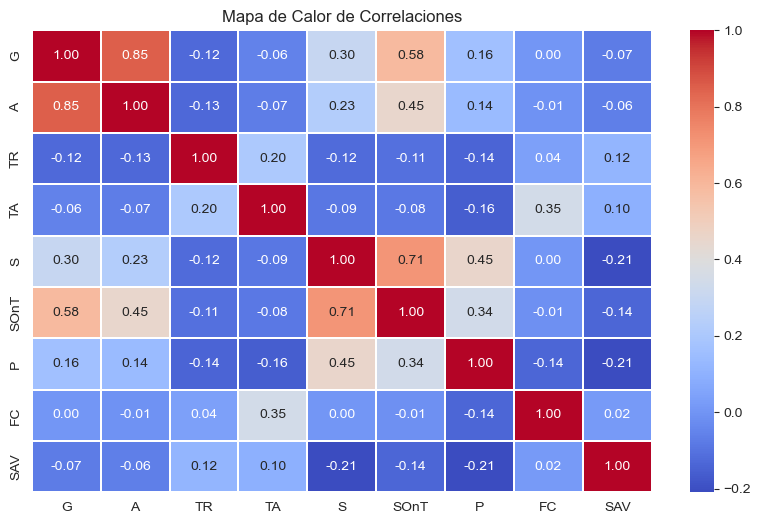

In [11]:
from sklearn.preprocessing import StandardScaler
# ========================
# Sección 7: Mapa de Calor de Correlaciones
# ========================
print("# Mapa de Calor de Correlaciones")

# Normalizar datos numéricos
cols = ['G', 'A', 'TR', 'TA', 'S', 'SOnT', 'P', 'FC', 'SAV']
df_num = df[cols].dropna()
ss = StandardScaler()
df_sc = ss.fit_transform(df_num)
df_sc = pd.DataFrame(df_sc, columns=cols)

# Crear matriz de correlaciones
corr = df_sc.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt='.2f', linewidths=.05)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [12]:
## Glosario de variables

# G Goles
# A Asistencias
# TR Tarjetas rojas
# TA Tarjetas amarillas
# Crn Corners won
# S Remates
# SOnT Remates a portería
# BS Remates bloqueados
# P Pases
# C Centros al área
# E Entradas
# O Fueras de juego
# FC Faltas cometidas
# FR Faltas recibidas
# SAV Paradas

# AP Accurate Passes
# HW Remate al palo
# SIB Remates desde dentro del área
# SOB Remates desde fuera del área
# HS Remates de cabeza
# GK Remate a gol
# Ti Saques de banda
# GOTB Goles desde fuera del área
# RFG Goles con la derecha
# LFG Goles con la izquierda
# HG Goles de cabeza
# PG Penalty goals
# GFSP Goles a balón parado

# Gráficos de Barras de Estadísticas de Equipos


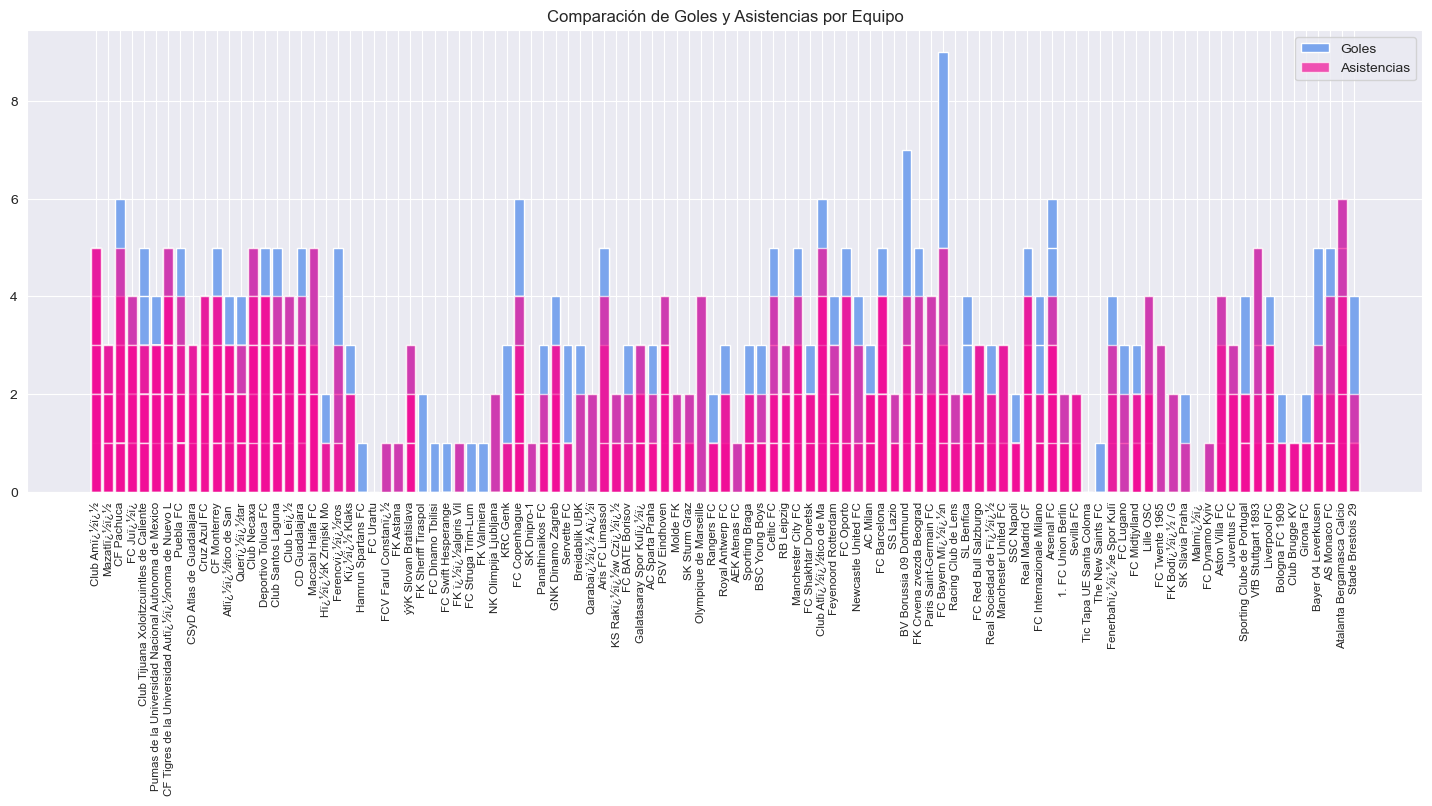

In [13]:
# ========================
# Sección 7: Gráficos de Barras Comparativos
# ========================
print("# Gráficos de Barras de Estadísticas de Equipos")

plt.figure(figsize=(18,6))
plt.bar(df["equipo"], df["G"], color="#7ba5ed", label="Goles")
plt.bar(df["equipo"], df["A"], color="#f20f97", label="Asistencias", alpha=0.7)
plt.xticks(rotation=90, fontsize='small')
plt.title("Comparación de Goles y Asistencias por Equipo")
plt.legend()
plt.grid(True)
plt.show()

## 3.1 Creación de un modelo para determinar al campeón de la Liga MX. 
Sabemos que el campeón de la temporada fue el Club de Fútbol Toluca, pero intentaremos realizar algún modelo ya sea un Random Forest, un clasificador de Naive Bayes o ¿Por qué no? Una red neuronal para tratar de determinar al campeón del torneo pasado. Por ahora, empezaremos con una breve limpieza de datos (otra vez).

In [14]:
df1 = df[df['liga'] == 'Liga MX']

In [15]:
df1.drop(['fecha'], axis=1)

,liga,temporada,equipo,sede,asistencia,arbitro,id,G,A,TR,...,Ti_rival,GOTB_rival,RFG_rival,LFG_rival,HG_rival,PG_rival,GFSP_rival,contrincante_rival,posicion_rival,fecha_convertida
0,Liga MX,2023/2024,Club Amï¿½ï¿½,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,1,0,0,...,20,1,2,0,0,0,0,Club Amï¿½ï¿½,Visitante,2023-06-30
1,Liga MX,2023/2024,Mazatlï¿½ï¿½,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,0,...,25,0,1,0,0,0,0,Mazatlï¿½ï¿½,Visitante,2023-06-30
2,Liga MX,2023/2024,CF Pachuca,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,0,...,20,0,1,0,0,0,0,CF Pachuca,Local,2023-06-30
3,Liga MX,2023/2024,FC Juï¿½ï¿,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,2,2,0,...,22,1,0,1,0,0,1,FC Juï¿½ï¿,Local,2023-06-30
4,Liga MX,2023/2024,Club Tijuana Xoloitzcuintles de Caliente,Estadio Caliente,26333.0,Daniel Quintero Huittrï¿½,tijuana.xoloitzcuintles.caliente_pumas.la.univ...,2,1,0,...,23,0,3,0,0,1,0,Club Tijuana Xoloitzcuintles de Caliente,Visitante,2023-06-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,Liga MX,2024/2025,Club Leï¿½,Estadio Leï¿½ï¿½n (Nou Ca,25425.0,Marco Antonio Ortï¿½ï¿½z,leï¿½ï¿½n_toluca_802,3,3,0,...,13,0,3,0,0,0,0,Club Leï¿½,Visitante,2025-02-08
1800,Liga MX,2024/2025,Club Tijuana Xoloitzcuintles de Caliente,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,1,1,1,...,22,0,1,1,0,0,0,Club Tijuana Xoloitzcuintles de Caliente,Local,2025-02-09
1801,Liga MX,2024/2025,Mazatlï¿½ï¿½,Estadio Olï¿½ï¿½mpico Universita,8845.0,Vï¿½ï¿½ctor Alfonso Cï¿½ï¿½ceres He,pumas.la.universidad.nacional.autonoma.mexico_...,0,0,0,...,25,0,1,0,0,0,0,Mazatlï¿½ï¿½,Local,2025-02-09
1802,Liga MX,2024/2025,CD Guadalajara,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,2,2,0,...,23,0,0,0,1,0,0,CD Guadalajara,Visitante,2025-02-09


In [16]:
mapeo_equipos = {
    "Club Amï¿½ï¿½": "América",
    "Mazatlï¿½ï¿½": "Mazatlán",
    "CF Pachuca": "Pachuca",
    "FC Juï¿½ï¿": "Juárez",
    "Club Tijuana Xoloitzcuintles de Caliente": "Tijuana",
    "Pumas de la Universidad Nacional Autonoma de Mexico": "Pumas",
    "CF Tigres de la Universidad Autï¿½ï¿½noma de Nuevo L": "Tigres",
    "Puebla FC": "Puebla",
    "CSyD Atlas de Guadalajara": "Atlas",
    "Cruz Azul FC": "Cruz Azul",
    "CF Monterrey": "Monterrey",
    "Atlï¿½ï¿½tico de San": "Atlético San Luis",
    "Querï¿½ï¿½tar": "Querétaro",
    "Club Necaxa": "Necaxa",
    "Deportivo Toluca FC": "Toluca",
    "Club Santos Laguna": "Santos",
    "Club Leï¿½": "León",
    "CD Guadalajara": "Guadalajara"
}
df1["equipo"] = df1["equipo"].map(mapeo_equipos)

/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_3801/2785543572.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["equipo"] = df1["equipo"].map(mapeo_equipos)


In [17]:
df1["equipo_rival"]=df1["equipo_rival"].map(mapeo_equipos)
df1["contrincante"]=df1["contrincante"].map(mapeo_equipos)
df1["contrincante_rival"]=df1["contrincante_rival"].map(mapeo_equipos)

/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_3801/593587823.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["equipo_rival"]=df1["equipo_rival"].map(mapeo_equipos)
/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_3801/593587823.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["contrincante"]=df1["contrincante"].map(mapeo_equipos)
/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_3801/593587823.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [18]:
df1["equipo"].unique()

array(['América', 'Mazatlán', 'Pachuca', 'Juárez', 'Tijuana', 'Pumas',
       'Tigres', 'Puebla', 'Atlas', 'Cruz Azul', 'Monterrey', nan,
       'Querétaro', 'Necaxa', 'Toluca', 'Santos', 'León', 'Guadalajara'],
      dtype=object)

In [19]:
equipos_campeones = ["América"]

df1["campeon"] = df1["equipo"].apply(lambda x: 1 if x in equipos_campeones else 0) 


/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/ipykernel_3801/3040678752.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["campeon"] = df1["equipo"].apply(lambda x: 1 if x in equipos_campeones else 0)


In [20]:
df1

,liga,temporada,equipo,fecha,sede,asistencia,arbitro,id,G,A,...,GOTB_rival,RFG_rival,LFG_rival,HG_rival,PG_rival,GFSP_rival,contrincante_rival,posicion_rival,fecha_convertida,campeon
0,Liga MX,2023/2024,América,30 de junio de 2023,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,1,0,...,1,2,0,0,0,0,América,Visitante,2023-06-30,1
1,Liga MX,2023/2024,Mazatlán,30 de junio de 2023,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,...,0,1,0,0,0,0,Mazatlán,Visitante,2023-06-30,0
2,Liga MX,2023/2024,Pachuca,30 de junio de 2023,Estadio El Encanto,8479.0,Jesus Rafael Lopez Valle,mazatlï¿½ï¿½n_pachuca_3006,1,1,...,0,1,0,0,0,0,Pachuca,Local,2023-06-30,0
3,Liga MX,2023/2024,Juárez,30 de junio de 2023,Estadio Azteca,13391.0,Ismael Rosario Lopez Peï¿½ï¿½u,amï¿½ï¿½rica_juï¿½ï¿½rez_,2,2,...,1,0,1,0,0,1,Juárez,Local,2023-06-30,0
4,Liga MX,2023/2024,Tijuana,30 de junio de 2023,Estadio Caliente,26333.0,Daniel Quintero Huittrï¿½,tijuana.xoloitzcuintles.caliente_pumas.la.univ...,2,1,...,0,3,0,0,1,0,Tijuana,Visitante,2023-06-30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,Liga MX,2024/2025,León,8 de febrero de 2025,Estadio Leï¿½ï¿½n (Nou Ca,25425.0,Marco Antonio Ortï¿½ï¿½z,leï¿½ï¿½n_toluca_802,3,3,...,0,3,0,0,0,0,León,Visitante,2025-02-08,0
1800,Liga MX,2024/2025,Tijuana,9 de febrero de 2025,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,1,1,...,0,1,1,0,0,0,Tijuana,Local,2025-02-09,0
1801,Liga MX,2024/2025,Mazatlán,9 de febrero de 2025,Estadio Olï¿½ï¿½mpico Universita,8845.0,Vï¿½ï¿½ctor Alfonso Cï¿½ï¿½ceres He,pumas.la.universidad.nacional.autonoma.mexico_...,0,0,...,0,1,0,0,0,0,Mazatlán,Local,2025-02-09,0
1802,Liga MX,2024/2025,Guadalajara,9 de febrero de 2025,Estadio AKRON,24483.0,Fernando Hernï¿½ï¿½ndez Gï,guadalajara_tijuana.xoloitzcuintles.caliente_9...,2,2,...,0,0,0,1,0,0,Guadalajara,Visitante,2025-02-09,0


In [21]:
df1.columns

Index(['liga', 'temporada', 'equipo', 'fecha', 'sede', 'asistencia', 'arbitro',
       'id', 'G', 'A', 'TR', 'TA', 'Crn', 'S', 'SOnT', 'BS', 'P', 'C', 'E',
       'O', 'FC', 'FR', 'SAV', 'AP', 'HW', 'SIB', 'SOB', 'HS', 'GK', 'Ti',
       'GOTB', 'RFG', 'LFG', 'HG', 'PG', 'GFSP', 'contrincante', 'posicion',
       'liga_rival', 'temporada_rival', 'equipo_rival', 'fecha_rival',
       'sede_rival', 'asistencia_rival', 'arbitro_rival', 'G_rival', 'A_rival',
       'TR_rival', 'TA_rival', 'Crn_rival', 'S_rival', 'SOnT_rival',
       'BS_rival', 'P_rival', 'C_rival', 'E_rival', 'O_rival', 'FC_rival',
       'FR_rival', 'SAV_rival', 'AP_rival', 'HW_rival', 'SIB_rival',
       'SOB_rival', 'HS_rival', 'GK_rival', 'Ti_rival', 'GOTB_rival',
       'RFG_rival', 'LFG_rival', 'HG_rival', 'PG_rival', 'GFSP_rival',
       'contrincante_rival', 'posicion_rival', 'fecha_convertida', 'campeon'],
      dtype='object')

In [22]:
features = [
    'G', 'A', 'TR', 'TA', 'Crn', 'S', 'SOnT', 'BS', 'P', 'C', 'E',
    'O', 'FC', 'FR', 'SAV', 'AP', 'HW', 'SIB', 'SOB', 'HS', 'GK', 'Ti',
    'GOTB', 'RFG', 'LFG', 'HG', 'PG', 'GFSP'
]

## Glosario de variables

# G Goles
# A Asistencias
# TR Tarjetas rojas
# TA Tarjetas amarillas
# Crn Corners won
# S Remates
# SOnT Remates a portería
# BS Remates bloqueados
# P Pases
# C Centros al área
# E Entradas
# O Fueras de juego
# FC Faltas cometidas
# FR Faltas recibidas
# SAV Paradas

# AP Accurate Passes
# HW Remate al palo
# SIB Remates desde dentro del área
# SOB Remates desde fuera del área
# HS Remates de cabeza
# GK Remate a gol
# Ti Saques de banda
# GOTB Goles desde fuera del área
# RFG Goles con la derecha
# LFG Goles con la izquierda
# HG Goles de cabeza
# PG Penalty goals
# GFSP Goles a balón parado

In [23]:
# Promediar las estadísticas por equipo y temporada
df_agg = df1.groupby(['equipo', 'temporada'])[features + ['campeon']].mean().reset_index()

In [24]:
X = df_agg[features]
y = df_agg['campeon']

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [25]:
df_agg['probabilidad_campeon'] = clf.predict_proba(X)[:, 1]

# Filtrar por temporada 2024/2025
df_filtrado = df_agg[df_agg['temporada'] == '2024/2025']

# Mostrar resultados ordenados
df_filtrado[['equipo', 'temporada', 'probabilidad_campeon']].sort_values(by='probabilidad_campeon', ascending=False)

,equipo,temporada,probabilidad_campeon
1,América,2024/2025,0.24
33,Toluca,2024/2025,0.14
31,Tijuana,2024/2025,0.11
5,Cruz Azul,2024/2025,0.06
9,Juárez,2024/2025,0.06
17,Necaxa,2024/2025,0.06
19,Pachuca,2024/2025,0.01
21,Puebla,2024/2025,0.01
23,Pumas,2024/2025,0.01
27,Santos,2024/2025,0.01
